# Predicción de cancelación de clientes

**Caso base de la tarea — Curso de Despliegue y Producción de Modelos de ML**

---

## El problema

Una empresa de suscripciones quiere saber **qué clientes están por darse de baja**,
para poder contactarlos antes de que se vayan.

Tenemos 6.000 clientes con su historial, y sabemos cuáles cancelaron. Vamos a
entrenar un modelo que, dado un cliente, estime **la probabilidad de que cancele**.

## Qué hace este notebook

1. Carga y explora los datos
2. Arma un pipeline de preprocesamiento + modelo
3. Entrena
4. **Evalúa el modelo con detalle** — esta es la parte larga, y a propósito
5. Prueba el modelo con un cliente nuevo

## Qué NO hace este notebook

No guarda el modelo. **Eso es tu tarea**, y está al final, en la sección marcada
`TAREA`. Leé todo el notebook antes de llegar ahí: vas a necesitar entender qué
produce cada paso.


## 1. Configuración

In [1]:
# joblib permite guardar y volver a cargar el pipeline entrenado.
import joblib
# matplotlib se usa para crear los gráficos de exploración y evaluación.
import matplotlib.pyplot as plt
# numpy aporta operaciones numéricas y su versión para comprobar el entorno.
import numpy as np
# pandas permite cargar, transformar y analizar los datos tabulares.
import pandas as pd
# sklearn contiene las herramientas de preprocesamiento, entrenamiento y evaluación.
import sklearn

# ColumnTransformer aplica transformaciones diferentes según el tipo de columna.
from sklearn.compose import ColumnTransformer
# LogisticRegression clasifica clientes en las clases 0 (sigue) y 1 (cancela).
from sklearn.linear_model import LogisticRegression
# Importamos métricas para medir distintos aspectos del rendimiento del clasificador.
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
# cross_val_score evalúa la estabilidad; train_test_split separa datos de entrenamiento y prueba.
from sklearn.model_selection import cross_val_score, train_test_split
# Pipeline agrupa el preprocesamiento y el modelo para aplicar siempre los mismos pasos.
from sklearn.pipeline import Pipeline
# OneHotEncoder convierte categorías de texto en columnas numéricas; StandardScaler normaliza números.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# None evita que pandas oculte columnas al mostrar tablas anchas.
pd.set_option("display.max_columns", None)
# Define el tamaño base de los gráficos: 11 pulgadas de ancho y 4 de alto.
plt.rcParams["figure.figsize"] = (11, 4)

# Mostramos las versiones para poder reproducir o diagnosticar el entorno de ejecución.
print("pandas ", pd.__version__)
print("numpy  ", np.__version__)
print("sklearn", sklearn.__version__)
print("joblib ", joblib.__version__)

pandas  3.0.5
numpy   2.5.2
sklearn 1.9.0
joblib  1.5.3


## 2. Los datos

Cada fila es un cliente. La columna `cancelo` es lo que queremos predecir:
vale 1 si el cliente se dio de baja y 0 si sigue activo.

In [2]:
# Carga el archivo CSV; la ruta es relativa a la carpeta desde la que se ejecuta el notebook.
clientes = pd.read_csv("clientes.csv")

# len() cuenta las filas, es decir, el número de clientes disponibles.
print("Filas:", len(clientes))
# list() muestra los nombres de todas las variables incluidas en el archivo.
print("Columnas:", list(clientes.columns))
# head() muestra las primeras cinco filas para revisar rápidamente el formato de los datos.
clientes.head()

Filas: 6000
Columnas: ['antiguedad_meses', 'gasto_mensual', 'visitas_ultimo_mes', 'dias_desde_ultima_visita', 'tickets_soporte', 'plan', 'metodo_pago', 'descuento_activo', 'cancelo']


,antiguedad_meses,gasto_mensual,visitas_ultimo_mes,dias_desde_ultima_visita,tickets_soporte,plan,metodo_pago,descuento_activo,cancelo
0,16,17.93,9,20,0,estandar,tarjeta,0,0
1,10,11.50,4,2,0,basico,tarjeta,0,0
2,6,48.49,1,18,0,premium,tarjeta,1,0
3,12,26.11,0,6,2,estandar,tarjeta,0,0
4,34,13.88,6,45,0,basico,tarjeta,0,1


### Qué significa cada columna

| Columna | Tipo | Qué es |
|---|---|---|
| `antiguedad_meses` | número | meses que lleva como cliente |
| `gasto_mensual` | número | cuánto paga por mes |
| `visitas_ultimo_mes` | número | veces que usó el servicio en el último mes |
| `dias_desde_ultima_visita` | número | días desde la última vez que lo usó |
| `tickets_soporte` | número | reclamos abiertos en el último mes |
| `plan` | texto | `basico`, `estandar` o `premium` |
| `metodo_pago` | texto | `tarjeta`, `transferencia` o `efectivo` |
| `descuento_activo` | 0 o 1 | si hoy tiene un descuento aplicado |
| **`cancelo`** | 0 o 1 | **lo que queremos predecir** |

In [3]:
# describe() resume las columnas numéricas con conteo, media, desviación y percentiles.
# T() transpone la tabla para mostrar una variable por fila; round(2) limita a dos decimales.
clientes.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
antiguedad_meses,6000.0,15.58,10.42,1.0,8.00,13.00,21.00,60.00
gasto_mensual,6000.0,23.04,12.94,5.0,12.47,20.57,29.07,58.39
visitas_ultimo_mes,6000.0,6.98,4.07,0.0,4.00,7.00,9.00,29.00
dias_desde_ultima_visita,6000.0,20.98,19.98,0.0,6.00,15.00,29.00,90.00
tickets_soporte,6000.0,0.61,0.82,0.0,0.00,0.00,1.00,5.00
descuento_activo,6000.0,0.22,0.42,0.0,0.00,0.00,0.00,1.00
cancelo,6000.0,0.32,0.47,0.0,0.00,0.00,1.00,1.00


### ¿Está balanceado?

In [4]:
# value_counts() cuenta cuántos clientes pertenecen a cada clase de cancelación.
print(clientes.cancelo.value_counts())
print()
# La media de una columna 0/1 equivale a la proporción de clientes que cancelaron.
# :.1% convierte esa proporción decimal a porcentaje con un decimal visible.
print(f"Tasa de cancelación: {clientes.cancelo.mean():.1%}")

cancelo
0    4063
1    1937
Name: count, dtype: int64

Tasa de cancelación: 32.3%


Un 32% de cancelación. **No está balanceado, pero tampoco es un caso extremo.**

Esto importa para elegir la métrica: si el modelo dijera "nadie cancela" para
todos, acertaría el 68% de las veces. Por eso la *accuracy* sola no alcanza, y
más abajo vamos a mirar precisión, recall y AUC.

## 3. Exploración: ¿qué separa a los que cancelan?

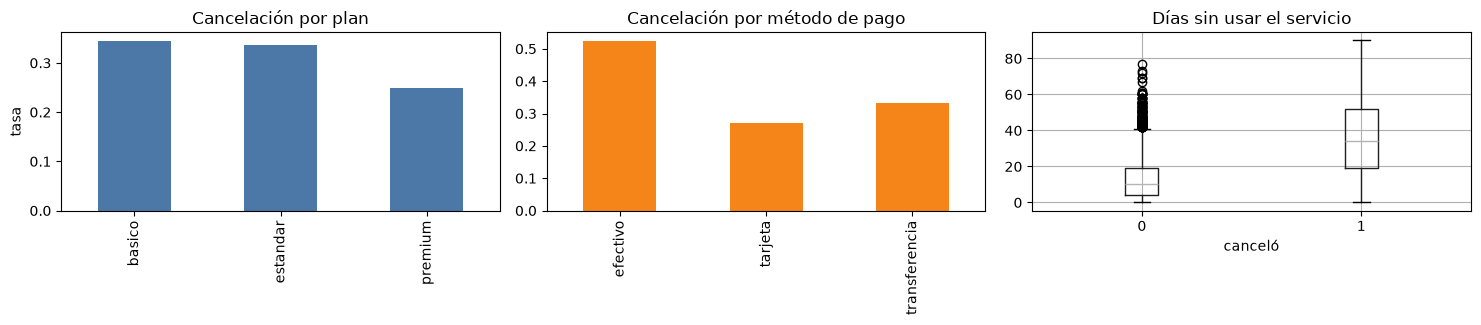

In [5]:
# Crea una figura con tres ejes en una fila; figsize se expresa en pulgadas.
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))

# Agrupa por plan, calcula la tasa media de cancelación y la dibuja como barras.
clientes.groupby("plan").cancelo.mean().plot.bar(ax=ax[0], color="#4C78A8")
ax[0].set_title("Cancelación por plan"); ax[0].set_ylabel("tasa"); ax[0].set_xlabel("")

# Repite el análisis agrupando por método de pago y usa un color diferente.
clientes.groupby("metodo_pago").cancelo.mean().plot.bar(ax=ax[1], color="#F58518")
ax[1].set_title("Cancelación por método de pago"); ax[1].set_xlabel("")

# Compara la distribución de días sin visita entre clientes que cancelaron y que siguieron.
clientes.boxplot(column="dias_desde_ultima_visita", by="cancelo", ax=ax[2])
ax[2].set_title("Días sin usar el servicio"); ax[2].set_xlabel("canceló")
# Elimina el título automático de pandas, ajusta espacios y muestra la figura.
plt.suptitle("")
plt.tight_layout(); plt.show()

**Lectura:**

- Quien paga en **efectivo** cancela mucho más que quien paga con tarjeta. Tiene
  sentido: el pago manual da una oportunidad de decidir no pagar todos los meses.
- **Premium** retiene mejor que los otros planes.
- Los que cancelaron llevaban **más días sin usar el servicio**. Es la señal más
  fuerte del dataset, y también la más accionable.

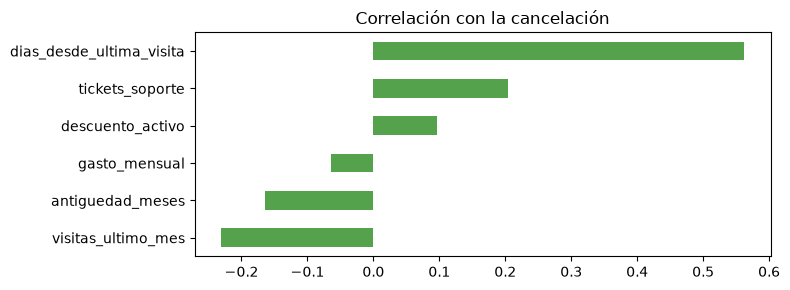

dias_desde_ultima_visita    0.563
tickets_soporte             0.205
descuento_activo            0.096
gasto_mensual              -0.064
antiguedad_meses           -0.164
visitas_ultimo_mes         -0.231
Name: cancelo, dtype: float64

In [6]:
# Lista las variables numéricas cuya correlación con la cancelación queremos inspeccionar.
numericas = ["antiguedad_meses", "gasto_mensual", "visitas_ultimo_mes",
             "dias_desde_ultima_visita", "tickets_soporte", "descuento_activo"]

# Selecciona las variables numéricas y el objetivo, calcula sus correlaciones y
# elimina la correlación del objetivo consigo mismo, que siempre sería 1.
correlaciones = clientes[numericas + ["cancelo"]].corr()["cancelo"].drop("cancelo")
# Ordena las correlaciones y muestra las negativas y positivas en un gráfico horizontal.
correlaciones.sort_values().plot.barh(color="#54A24B", figsize=(8, 3))
plt.title("Correlación con la cancelación"); plt.tight_layout(); plt.show()

# Devuelve los valores ordenados de mayor a menor para identificar las señales más fuertes.
correlaciones.sort_values(ascending=False).round(3)

## 4. Separar los datos

`X` son las variables de entrada y `y` es lo que queremos predecir.

Fijate en que **`cancelo` no está en `X`**. Si estuviera, el modelo tendría la
respuesta y aprendería nada.

In [8]:
# Separamos las columnas numéricas y categóricas para aplicarles tratamientos diferentes.
COLUMNAS_NUMERICAS = ["antiguedad_meses", "gasto_mensual", "visitas_ultimo_mes",
                      "dias_desde_ultima_visita", "tickets_soporte", "descuento_activo"]
COLUMNAS_CATEGORICAS = ["plan", "metodo_pago"]

# Esta lista contiene exactamente las variables que el modelo puede usar como entrada.
COLUMNAS = COLUMNAS_NUMERICAS + COLUMNAS_CATEGORICAS

# X contiene las características de entrada; y contiene la etiqueta 0/1 que predecimos.
X = clientes[COLUMNAS]
y = clientes["cancelo"]

# Divide los datos en entrenamiento y prueba sin modificar X ni y originales.
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y,
    test_size=0.25,       # Reserva el 25% para evaluar el modelo con datos no vistos.
    random_state=42,      # Fija la semilla para obtener la misma división al repetir el proceso.
    stratify=y,           # Mantiene la misma proporción de cancelaciones en las dos partes.
)

# Comprueba cuántos clientes quedaron en cada conjunto y que sus tasas sean comparables.
print(f"Entrenamiento: {len(X_entrena):,} clientes")
print(f"Prueba       : {len(X_prueba):,} clientes")
print(f"\nTasa de cancelación — entrenamiento: {y_entrena.mean():.1%}, prueba: {y_prueba.mean():.1%}")

Entrenamiento: 4,500 clientes
Prueba       : 1,500 clientes

Tasa de cancelación — entrenamiento: 32.3%, prueba: 32.3%


> **Por qué `stratify=y`:** sin eso, el azar podría dejar 40% de cancelaciones en
> una parte y 25% en la otra, y la evaluación mediría el desbalance en vez del
> modelo.

## 5. El pipeline

Las columnas necesitan tratamientos distintos:

- las **numéricas** se escalan, para que `gasto_mensual` (que llega a 58) no pese
  más que `tickets_soporte` (que llega a 5) solo por la magnitud
- las **categóricas** (texto) hay que convertirlas a números, con *one-hot*:
  `plan` se convierte en tres columnas de 0 y 1

Un `Pipeline` junta el preprocesamiento y el modelo en **un solo objeto**.

> **Esto es lo más importante del notebook para tu tarea.** Como el pipeline
> incluye el preprocesamiento, cuando lo guardes y lo cargues en la API vas a
> poder pasarle el cliente **con los textos tal como vienen** (`plan="premium"`),
> sin tener que repetir la conversión a números. Si el preprocesamiento estuviera
> fuera del pipeline, tendrías que reproducirlo exactamente en la API — y ahí es
> donde se rompen los modelos en producción.

In [12]:
# Aplica StandardScaler a las columnas numéricas para centrar y escalar sus magnitudes.
# OneHotEncoder convierte las categorías de texto en columnas binarias; ignore evita errores
# si aparece una categoría nueva al predecir en producción.
preprocesamiento = ColumnTransformer([
    ("numericas", StandardScaler(), COLUMNAS_NUMERICAS),
    ("categoricas", OneHotEncoder(handle_unknown="ignore"), COLUMNAS_CATEGORICAS),
])

# Pipeline ejecuta primero el preprocesamiento y después el clasificador en el mismo objeto.
modelo = Pipeline([
    ("preprocesamiento", preprocesamiento),
    # max_iter=1000 permite hasta 1000 iteraciones para que el optimizador converja.
    # random_state=42 hace reproducible cualquier componente aleatorio del clasificador.
    ("clasificador", LogisticRegression(max_iter=1000, random_state=42)),
])

# Mostrar el pipeline permite revisar sus pasos antes de entrenarlo.
modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold:

`handle_unknown="ignore"` significa: si en producción llega un plan que el
modelo nunca vio, no explota. Lo trata como si todas las categorías fueran cero.

No es lo ideal —conviene rechazarlo en la API, y eso es parte de tu tarea— pero
evita que el servicio se caiga.

## 6. Entrenar

In [13]:
# fit() aprende los parámetros del preprocesamiento y los coeficientes del modelo
# usando únicamente las filas de entrenamiento y sus etiquetas correspondientes.
modelo.fit(X_entrena, y_entrena)

print("Modelo entrenado.")

Modelo entrenado.


## 7. Evaluación

Acá está el trabajo real. Un modelo no se juzga con un solo número.

### 7.1 Las cuatro métricas básicas

In [14]:
# predict() devuelve la clase final (0 o 1) usando el umbral predeterminado de 0.5.
prediccion = modelo.predict(X_prueba)
# predict_proba() devuelve una probabilidad por clase; [:, 1] selecciona la clase 1 (cancela).
probabilidad = modelo.predict_proba(X_prueba)[:, 1]

# Calcula métricas complementarias para evaluar aciertos, falsas alarmas y detecciones.
exactitud = accuracy_score(y_prueba, prediccion)       # Proporción total de predicciones correctas.
precision = precision_score(y_prueba, prediccion)      # De los marcados, proporción que realmente cancela.
sensibilidad = recall_score(y_prueba, prediccion)      # De los que cancelan, proporción detectada.
f1 = f1_score(y_prueba, prediccion)                    # Media armónica entre precision y recall.
auc = roc_auc_score(y_prueba, probabilidad)            # Capacidad de ordenar casos de menor a mayor riesgo.

# Formateamos cada métrica para mostrarla con cuatro decimales y una explicación breve.
print(f"Accuracy  : {exactitud:.4f}   de cada 100 clientes, acierta en {exactitud*100:.0f}")
print(f"Precision : {precision:.4f}   de los que marca como 'va a cancelar', acierta {precision*100:.0f}%")
print(f"Recall    : {sensibilidad:.4f}   de los que realmente cancelan, detecta {sensibilidad*100:.0f}%")
print(f"F1        : {f1:.4f}   el equilibrio entre las dos anteriores")
print(f"ROC-AUC   : {auc:.4f}   qué tan bien separa a los dos grupos")

Accuracy  : 0.8527   de cada 100 clientes, acierta en 85
Precision : 0.8215   de los que marca como 'va a cancelar', acierta 82%
Recall    : 0.6942   de los que realmente cancelan, detecta 69%
F1        : 0.7525   el equilibrio entre las dos anteriores
ROC-AUC   : 0.9055   qué tan bien separa a los dos grupos


### 7.2 Qué significa cada una, en este caso

| Métrica | Qué responde | Por qué importa acá |
|---|---|---|
| **Accuracy** | ¿Cuántos acertó en total? | Engaña con datos desbalanceados: decir "nadie cancela" da 68% |
| **Precision** | De los que marqué, ¿cuántos cancelaron? | Si es baja, el equipo comercial pierde tiempo llamando a gente que no se iba a ir |
| **Recall** | De los que cancelaron, ¿cuántos detecté? | Si es bajo, se te escapan los clientes que querías salvar |
| **ROC-AUC** | ¿Ordena bien por riesgo? | No depende del umbral. Es la métrica más honesta para comparar modelos |

**Precision y recall se pelean entre sí.** Si bajás el umbral, marcás más gente:
detectás más cancelaciones (recall sube) pero te equivocás más (precision baja).
Cuál conviene depende de cuánto cuesta llamar a un cliente contra cuánto vale
retenerlo.

### 7.3 La matriz de confusión

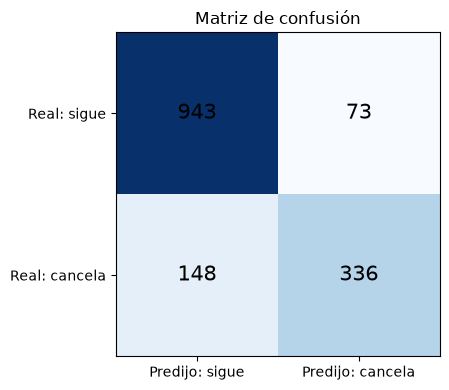

Acertó que seguían  : 943
Acertó que cancelan: 336
Falsa alarma       : 73  (los marcó y no se iban)
Se le escaparon    : 148  (cancelaron y no los detectó)


In [15]:
# confusion_matrix cuenta cada combinación de etiqueta real y predicción.
matriz = confusion_matrix(y_prueba, prediccion)

# Crea un gráfico cuadrado de cinco por cuatro pulgadas para visualizar la matriz.
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(matriz, cmap="Blues")  # cmap colorea los conteos: tonos más oscuros indican más casos.
# Escribe el conteo de cada celda; i representa la fila real y j la columna predicha.
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matriz[i, j]:,}", ha="center", va="center", fontsize=15)
# Etiqueta las columnas como predicciones y las filas como valores reales.
ax.set_xticks([0, 1], ["Predijo: sigue", "Predijo: cancela"])
ax.set_yticks([0, 1], ["Real: sigue", "Real: cancela"])
ax.set_title("Matriz de confusión")
plt.tight_layout(); plt.show()

# ravel() devuelve las cuatro celdas en el orden TN, FP, FN y TP.
verdaderos_negativos, falsos_positivos, falsos_negativos, verdaderos_positivos = matriz.ravel()
print(f"Acertó que seguían  : {verdaderos_negativos:,}")
print(f"Acertó que cancelan: {verdaderos_positivos:,}")
print(f"Falsa alarma       : {falsos_positivos:,}  (los marcó y no se iban)")
print(f"Se le escaparon    : {falsos_negativos:,}  (cancelaron y no los detectó)")

### 7.4 El reporte completo

In [16]:
# classification_report resume precision, recall y F1 para cada clase.
# target_names reemplaza 0/1 por nombres legibles; digits=3 muestra tres decimales.
print(classification_report(y_prueba, prediccion,
                            target_names=["Sigue activo", "Cancela"], digits=3))

              precision    recall  f1-score   support

Sigue activo      0.864     0.928     0.895      1016
     Cancela      0.822     0.694     0.753       484

    accuracy                          0.853      1500
   macro avg      0.843     0.811     0.824      1500
weighted avg      0.851     0.853     0.849      1500



### 7.5 La curva ROC

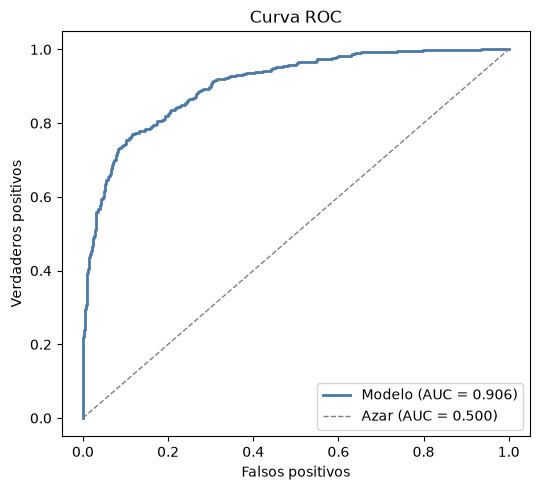

In [17]:
# roc_curve calcula la tasa de falsos positivos y verdaderos positivos para muchos umbrales.
fpr, tpr, _ = roc_curve(y_prueba, probabilidad)

# Crea una figura cuadrada para comparar el modelo con una clasificación al azar.
plt.figure(figsize=(5.5, 5))
# lw=2 define el grosor de la línea y label agrega la leyenda con el AUC calculado.
plt.plot(fpr, tpr, lw=2, label=f"Modelo (AUC = {auc:.3f})", color="#4C78A8")
# La diagonal representa el azar: la tasa de verdaderos positivos iguala a la de falsos positivos.
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Azar (AUC = 0.500)")
plt.xlabel("Falsos positivos"); plt.ylabel("Verdaderos positivos")
plt.title("Curva ROC"); plt.legend(); plt.tight_layout(); plt.show()

Cuanto más se despega la curva de la diagonal, mejor separa el modelo.

Una referencia práctica para leer el AUC: 0.5 es azar, 0.7 es aceptable, 0.8 es
bueno y arriba de 0.9 es muy bueno **para este tipo de problema**. Un AUC de 0.99
en datos de negocio suele ser señal de que se coló una variable que no debería
estar ahí.

### 7.6 ¿Y si cambiamos el umbral?

Por defecto, `predict()` marca como "cancela" a todo el que supere 0.5 de
probabilidad. Ese número **es una decisión de negocio, no del modelo**.

In [18]:
# Mostramos las columnas de la tabla con anchos fijos para facilitar la comparación.
print(f"{'umbral':>8}{'marcados':>10}{'precision':>11}{'recall':>9}{'F1':>8}")
# Probamos varios umbrales: un cliente se marca como cancelación si su probabilidad los alcanza.
for umbral in [0.3, 0.4, 0.5, 0.6, 0.7]:
    # >= convierte probabilidades en 0/1; astype(int) asegura etiquetas enteras.
    pred_umbral = (probabilidad >= umbral).astype(int)
    # zero_division=0 evita una excepción si ningún cliente queda marcado como positivo.
    print(f"{umbral:>8.1f}{pred_umbral.sum():>10,}"
          f"{precision_score(y_prueba, pred_umbral, zero_division=0):>11.3f}"
          f"{recall_score(y_prueba, pred_umbral):>9.3f}"
          f"{f1_score(y_prueba, pred_umbral):>8.3f}")

  umbral  marcados  precision   recall      F1
     0.3       586      0.669    0.810   0.733
     0.4       485      0.763    0.764   0.764
     0.5       409      0.822    0.694   0.753
     0.6       333      0.865    0.595   0.705
     0.7       281      0.890    0.517   0.654


Mirá cómo se mueven: **bajar el umbral detecta más cancelaciones pero genera
más falsas alarmas.**

Si el equipo comercial puede llamar a 500 clientes por mes, elegís el umbral que
te dé 500 marcados. Si llamar es caro, subís el umbral para equivocarte menos.

Guardá este número: **el umbral va a ser parte del bundle de tu tarea.**

### 7.7 ¿El resultado es estable?

Una sola partición puede haber tenido suerte. La validación cruzada entrena cinco
veces con particiones distintas.

In [19]:
# Evalúa el pipeline completo en cinco particiones distintas usando ROC-AUC como métrica.
# cv=5 significa que cada partición se usa una vez como validación y cuatro como entrenamiento.
puntajes = cross_val_score(modelo, X, y, cv=5, scoring="roc_auc")

# Muestra el AUC de cada partición y resume su media y desviación estándar.
print("AUC en cada partición:", puntajes.round(4))
print(f"\nPromedio: {puntajes.mean():.4f}  (±{puntajes.std():.4f})")

AUC en cada partición: [0.9194 0.9133 0.8891 0.8927 0.9066]

Promedio: 0.9042  (±0.0116)


Una desviación chica significa que el resultado no depende de cómo partimos los
datos. Si variara mucho, no podríamos confiar en el número del conjunto de prueba.

### 7.8 ¿Qué mira el modelo?

Como es una regresión logística, los coeficientes se pueden leer: positivo
empuja hacia cancelar, negativo hacia quedarse.

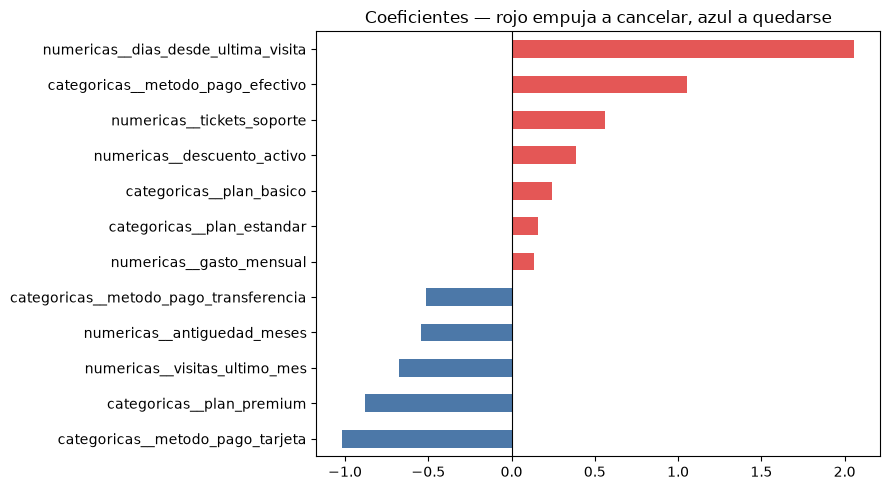

numericas__dias_desde_ultima_visita       2.059
categoricas__metodo_pago_efectivo         1.054
categoricas__metodo_pago_tarjeta         -1.018
categoricas__plan_premium                -0.880
numericas__visitas_ultimo_mes            -0.674
numericas__tickets_soporte                0.561
numericas__antiguedad_meses              -0.544
categoricas__metodo_pago_transferencia   -0.514
numericas__descuento_activo               0.387
categoricas__plan_basico                  0.244
categoricas__plan_estandar                0.158
numericas__gasto_mensual                  0.136
dtype: float64

In [20]:
# Recupera los nombres de las columnas después de escalar y aplicar one-hot encoding.
nombres = modelo.named_steps["preprocesamiento"].get_feature_names_out()
# coef_[0] contiene el peso aprendido por la regresión logística para cada característica.
coeficientes = modelo.named_steps["clasificador"].coef_[0]

# Asocia cada coeficiente con su nombre y ordénalos de menor a mayor.
importancia = pd.Series(coeficientes, index=nombres).sort_values()
# Los coeficientes positivos aparecen en rojo (empujan a cancelar) y los negativos en azul.
importancia.plot.barh(figsize=(9, 5),
                      color=["#E45756" if c > 0 else "#4C78A8" for c in importancia])
plt.title("Coeficientes — rojo empuja a cancelar, azul a quedarse")
plt.axvline(0, color="black", lw=0.8)  # La línea cero separa efectos positivos y negativos.
plt.tight_layout(); plt.show()

# Ordena por valor absoluto para identificar las variables con mayor efecto, sin importar el signo.
importancia.sort_values(key=abs, ascending=False).round(3)

**Coincide con lo que vimos en la exploración**, y eso es buena señal: pagar en
efectivo y llevar días sin usar el servicio empujan a cancelar; la antigüedad y
las visitas retienen.

Cuando un modelo "aprende" algo que contradice el negocio, casi siempre hay un
problema en los datos.

## 8. Probarlo con un cliente nuevo

Así se usa el modelo, y así lo va a usar tu API.

In [36]:
# Construye un DataFrame con una sola fila y los mismos nombres de columnas usados en el entrenamiento.
cliente_nuevo = pd.DataFrame([{
    "antiguedad_meses": 10,          # Tiempo que el cliente lleva suscrito.
    "gasto_mensual": 14.0,            # Importe mensual pagado por el cliente.
    "visitas_ultimo_mes": 4,          # Número de usos del servicio durante el último mes.
    "dias_desde_ultima_visita": 26,   # Días transcurridos desde el último uso.
    "tickets_soporte": 1,             # Reclamos o solicitudes abiertos durante el último mes.
    "plan": "basico",                 # Categoría del plan contratado.
    "metodo_pago": "efectivo",       # Forma de pago utilizada.
    "descuento_activo": 0,             # 0 indica que actualmente no tiene descuento.
}])

# [0, 1] selecciona la primera fila y la probabilidad de la clase 1 (cancela).
prob = modelo.predict_proba(cliente_nuevo)[0, 1]

# :.1% muestra la probabilidad como porcentaje; el umbral 0.5 decide la clase mostrada.
print(f"Probabilidad de cancelar: {prob:.1%}")
print("Predicción:", "CANCELA" if prob >= 0.5 else "sigue activo")

Probabilidad de cancelar: 88.1%
Predicción: CANCELA


Fijate en dos cosas, porque las vas a necesitar:

1. La entrada es un **DataFrame de una fila**, con las columnas por su nombre.
   El pipeline se encarga del resto: no hay que escalar ni convertir a números.
2. `predict_proba(...)[0, 1]` es **la probabilidad de la clase 1**. El `[0]` es la
   primera (y única) fila; el `[1]` es la columna de "cancela".

In [22]:
# Creamos un cliente con señales asociadas a menor riesgo para comparar su probabilidad.
cliente_fiel = pd.DataFrame([{
    "antiguedad_meses": 20,          # Cliente con más tiempo de permanencia.
    "gasto_mensual": 45.0,            # Gasto mensual más alto.
    "visitas_ultimo_mes": 8,          # Uso frecuente del servicio.
    "dias_desde_ultima_visita": 10,  # Pocos días desde la última visita.
    "tickets_soporte": 0,             # No abrió reclamos durante el último mes.
    "plan": "premium",                # Plan de categoría superior.
    "metodo_pago": "tarjeta",        # Pago automático o más habitual.
    "descuento_activo": 0,             # No tiene descuento activo.
}])

# Obtiene la probabilidad de la clase 1 para esta única fila del DataFrame.
print(f"Probabilidad de cancelar: {modelo.predict_proba(cliente_fiel)[0, 1]:.1%}")

Probabilidad de cancelar: 1.2%


---
---

# TAREA

Hasta acá llega el notebook que te entregamos. **Lo que sigue lo escribís vos.**

El modelo está entrenado y evaluado, pero vive en la memoria de este notebook:
cuando lo cierres, se pierde.

Tu tarea tiene tres partes, y están descritas en detalle en el documento
**`TAREA_bundle_y_api.md`**:

1. **Construir el bundle** — acá abajo, en este notebook
2. **Guardarlo y verificarlo** — acá abajo también
3. **Construir la API** — en archivos `.py` aparte

Leé el documento antes de empezar. Abajo quedan las celdas donde va la parte 1 y 2.


## TAREA · Parte 1 — Construir el bundle

Un diccionario con el modelo **y todo lo que la API va a necesitar saber**.

Repasá el documento de la tarea para ver qué claves tiene que tener y de dónde
sale cada valor. Casi todos los valores ya están calculados más arriba en este
notebook: buscalos, no los inventes.

In [23]:
# TAREA — Parte 1: armá el diccionario `bundle`
# Incluye el pipeline entrenado y los metadatos que la API necesitará para predecir.
# Completa las claves y valores siguiendo las instrucciones de TAREA_bundle_y_api.md.
from datetime import datetime
bundle = {
    "pipeline": modelo,
    "columnas": COLUMNAS,
    "metadata":{
        "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "Modelo": "Regresión logística",
    }
    
}

# Mostrarlo permite comprobar visualmente que contiene las claves esperadas.
bundle

{'pipeline': Pipeline(steps=[('preprocesamiento',
                  ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                   ['antiguedad_meses',
                                                    'gasto_mensual',
                                                    'visitas_ultimo_mes',
                                                    'dias_desde_ultima_visita',
                                                    'tickets_soporte',
                                                    'descuento_activo']),
                                                  ('categoricas',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['plan', 'metodo_pago'])])),
                 ('clasificador',
                  LogisticRegression(max_iter=1000, random_state=42))]),
 'columnas': ['antiguedad_meses',
  'gasto_mensual',
  'visitas_ultimo_mes',
  'dias

## TAREA · Parte 2 — Guardarlo y verificarlo

Guardar con `joblib.dump`, y después **volver a cargarlo y predecir**, para
comprobar que el archivo sirve de verdad.

In [24]:
# TAREA — Parte 2a: guarda el diccionario completo en un archivo Joblib.
# joblib.dump(objeto, ruta) serializa el objeto para poder cargarlo desde la API.
# Completa `bundle` y conserva este nombre de archivo para que coincida con la tarea.

joblib.dump(bundle, "bundle_clientChurn.joblib")

# TAREA — Parte 2b: carga el bundle guardado y vuelve a predecir con `cliente_nuevo`.
# joblib.load(ruta) reconstruye el diccionario y el pipeline en memoria.
# Comprueba que la probabilidad cargada sea EXACTAMENTE igual a la calculada arriba.

['bundle_clientChurn.joblib']

In [29]:
bundle_cargado = joblib.load("bundle_clientChurn.joblib")


In [ ]:
# Extrae el pipeline entrenado que está dentro del bundle.
pipeline_cargado = bundle_cargado["pipeline"]

# Vuelve a predecir usando exactamente el mismo cliente.
probabilidad_cargada = pipeline_cargado.predict_proba(cliente_nuevo)[0, 1]
print(f"Probabilidad de cancelar (cargada): {probabilidad_cargada:.1%}")

Probabilidad de cancelar (cargada): 88.1%


In [38]:
# Compara la probabilidad cargada con la calculada antes de guardar.
print(f"Probabilidad original: {prob:.15f}")
print(f"Probabilidad cargada : {probabilidad_cargada:.15f}")
# Comprueba que ambas probabilidades sean exactamente iguales.
assert probabilidad_cargada == prob

print("La probabilidad es exactamente igual.")


Probabilidad original: 0.881333120336493
Probabilidad cargada : 0.881333120336493
La probabilidad es exactamente igual.


In [ ]:
suscriptor_prueba1 = X_prueba.iloc[:1].to_dict()  # Tomamos la primera fila de prueba para simular un nuevo cliente.
suscriptor_prueba1

In [2]:
cliente_nuevo

NameError: name 'cliente_nuevo' is not defined

In [52]:
suscriptor_prueba1 = X_prueba.iloc[:1].to_dict(orient="records")[0]
print(suscriptor_prueba1)


{'antiguedad_meses': 6, 'gasto_mensual': 25.97, 'visitas_ultimo_mes': 9, 'dias_desde_ultima_visita': 27, 'tickets_soporte': 0, 'descuento_activo': 1, 'plan': 'estandar', 'metodo_pago': 'tarjeta'}


## TAREA · Parte 3 — La API

Esa parte no va en el notebook. Se hace en archivos `.py`, y está explicada en
el documento de la tarea.

> Antes de pasar a la parte 3, asegurate de que la parte 2 funcione: si el
> archivo no se puede cargar y predecir, la API no tiene con qué trabajar.
